# Telecom Customer Churn Prediction and Retention Analytics System

### Import Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

# 🎯 Problem Statement

Customer churn is one of the most significant challenges faced by telecommunication companies. Losing existing customers can lead to decreased revenue and increased customer acquisition costs.

The goal of this project is to build a Machine Learning classification model that predicts whether a customer is likely to churn based on customer demographics, service subscriptions, contract details, and billing information.

By identifying customers at risk of leaving, the company can implement targeted retention strategies, improve customer satisfaction, and reduce revenue loss.

### Objective
Develop a predictive model that classifies customers into:
- **Churn = Yes** (Customer will leave)
- **Churn = No** (Customer will stay)

### Expected Outcome
A machine learning model capable of accurately predicting customer churn and providing insights into the factors that influence customer retention.

# 📊 Telco Customer Churn Dataset

## 👤 Customer Information
- **customerID** – Unique customer identifier
- **gender** – Customer gender
- **SeniorCitizen** – Whether the customer is a senior citizen (0 = No, 1 = Yes)
- **Partner** – Whether the customer has a partner
- **Dependents** – Whether the customer has dependents

---

## 🤝 Customer Relationship
- **tenure** – Number of months the customer has stayed with the company

---

## 📞 Services Used
- **PhoneService** – Whether the customer has phone service
- **MultipleLines** – Whether the customer has multiple phone lines
- **InternetService** – Type of internet service
- **OnlineSecurity** – Online security service subscription
- **OnlineBackup** – Online backup service subscription
- **DeviceProtection** – Device protection plan subscription
- **TechSupport** – Technical support subscription
- **StreamingTV** – Streaming TV subscription
- **StreamingMovies** – Streaming movies subscription

---

## 📄 Contract & Payment Details
- **Contract** – Customer contract type
- **PaperlessBilling** – Whether paperless billing is enabled
- **PaymentMethod** – Customer payment method

---

## 💰 Billing Information
- **MonthlyCharges** – Monthly bill amount
- **TotalCharges** – Total amount charged to the customer

---

## 🎯 Target Variable
- **Churn** – Whether the customer left the company
  - **Yes** → Customer churned
  - **No** → Customer retained

---

## 📌 Dataset Summary

| Category | Features |
|-----------|-----------|
| Customer Information | customerID, gender, SeniorCitizen, Partner, Dependents |
| Customer Relationship | tenure |
| Services Used | PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies |
| Contract & Payment | Contract, PaperlessBilling, PaymentMethod |
| Billing Information | MonthlyCharges, TotalCharges |
| Target Variable | Churn |

**Total Features:** 20  
**Target Variable:** Churn (Classification Problem)

### Data loading and Exploring

In [2]:
df=pd.read_csv("Telco-Customer-Churn.csv")
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**Load & Preprocess Data**

In [3]:
# CHANGING DATA TYPE OF TotalCharges and handling null values
df["TotalCharges"]=pd.to_numeric(df["TotalCharges"],errors='coerce')

# FILLING NULL VALUES IN TOTAL CHARGES WITH EXACT AMOUNT IN  MONTHLY CHARGES BECAUSE TENURE WAS ZERO
df["TotalCharges"]=df["TotalCharges"].fillna(df["MonthlyCharges"]* df["tenure"])

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

# **EDA (Exploratory Data Analysis)**

# **Customer Churn By Customer Information**

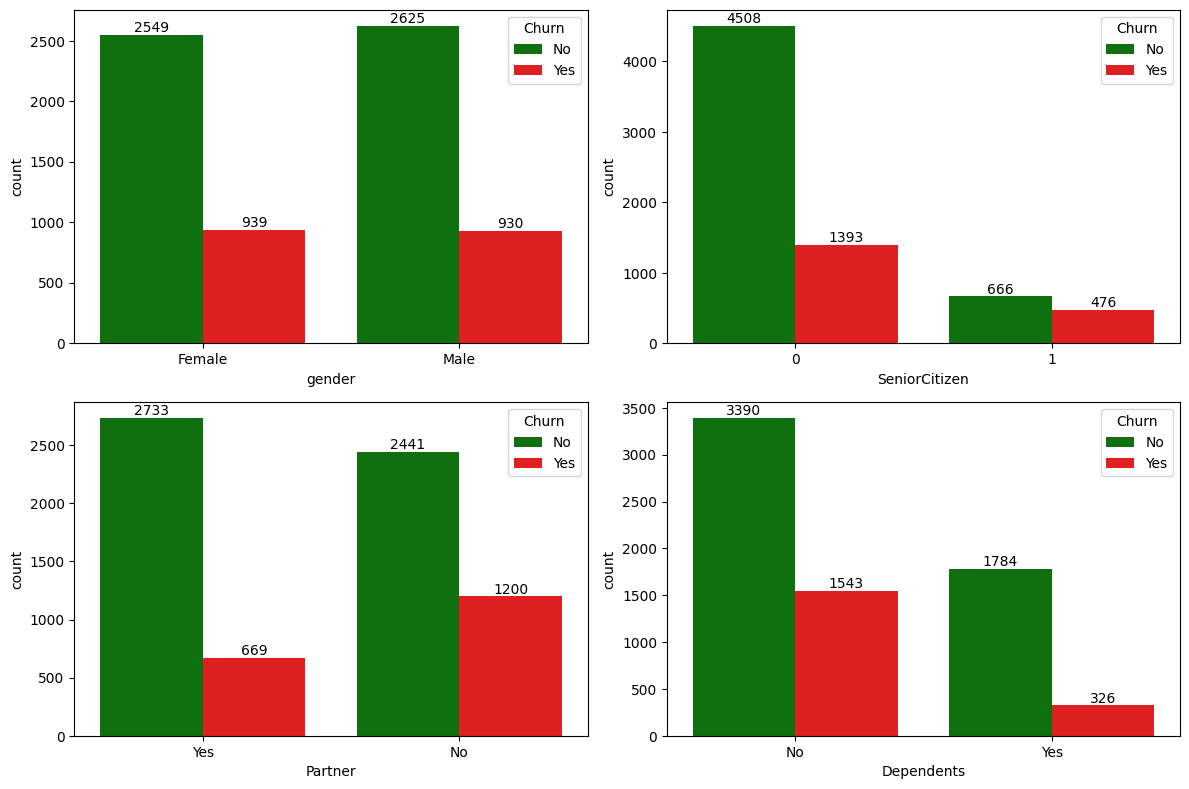

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

palette = {
    "Yes": "red",
    "No": "green"
}

sns.countplot(data=df, x="gender", hue="Churn", palette=palette, ax=axes[0,0])
sns.countplot(data=df, x="SeniorCitizen", hue="Churn", palette=palette, ax=axes[0,1])
sns.countplot(data=df, x="Partner", hue="Churn", palette=palette, ax=axes[1,0])
sns.countplot(data=df, x="Dependents", hue="Churn", palette=palette, ax=axes[1,1])

for ax in axes.flat:
    for container in ax.containers:
        ax.bar_label(container, fmt='%d')

plt.tight_layout()
plt.show()

##1. Gender shows minimal difference in churn — not a primary driver.
##2. Senior Citizens churns more than non-seniors.
##3. Customers without a partner churns more.

# **Customer Churn By Relationship**

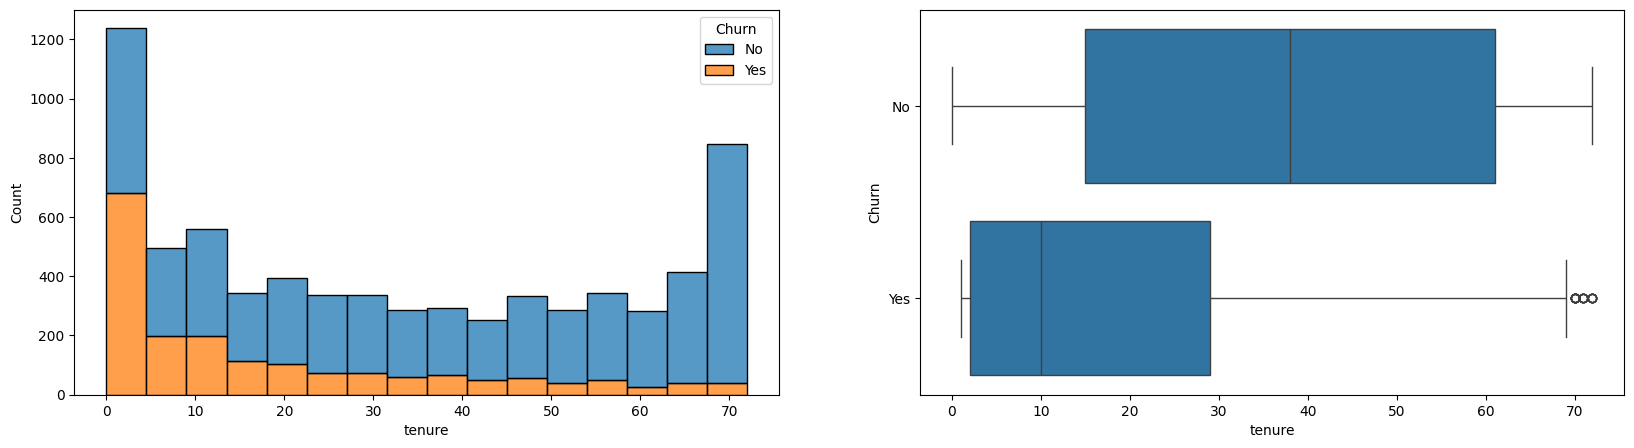

In [7]:
# Tenure Distribution & Oulier Detection

fig,axes=plt.subplots(1,2,figsize=(20,5))

sns.histplot(data=df, x="tenure", hue="Churn",multiple='stack',ax=axes[0])
sns.boxplot(data=df,y="Churn",x="tenure",ax=axes[1])

plt.show()

# Customer Churn by "individual" tenure

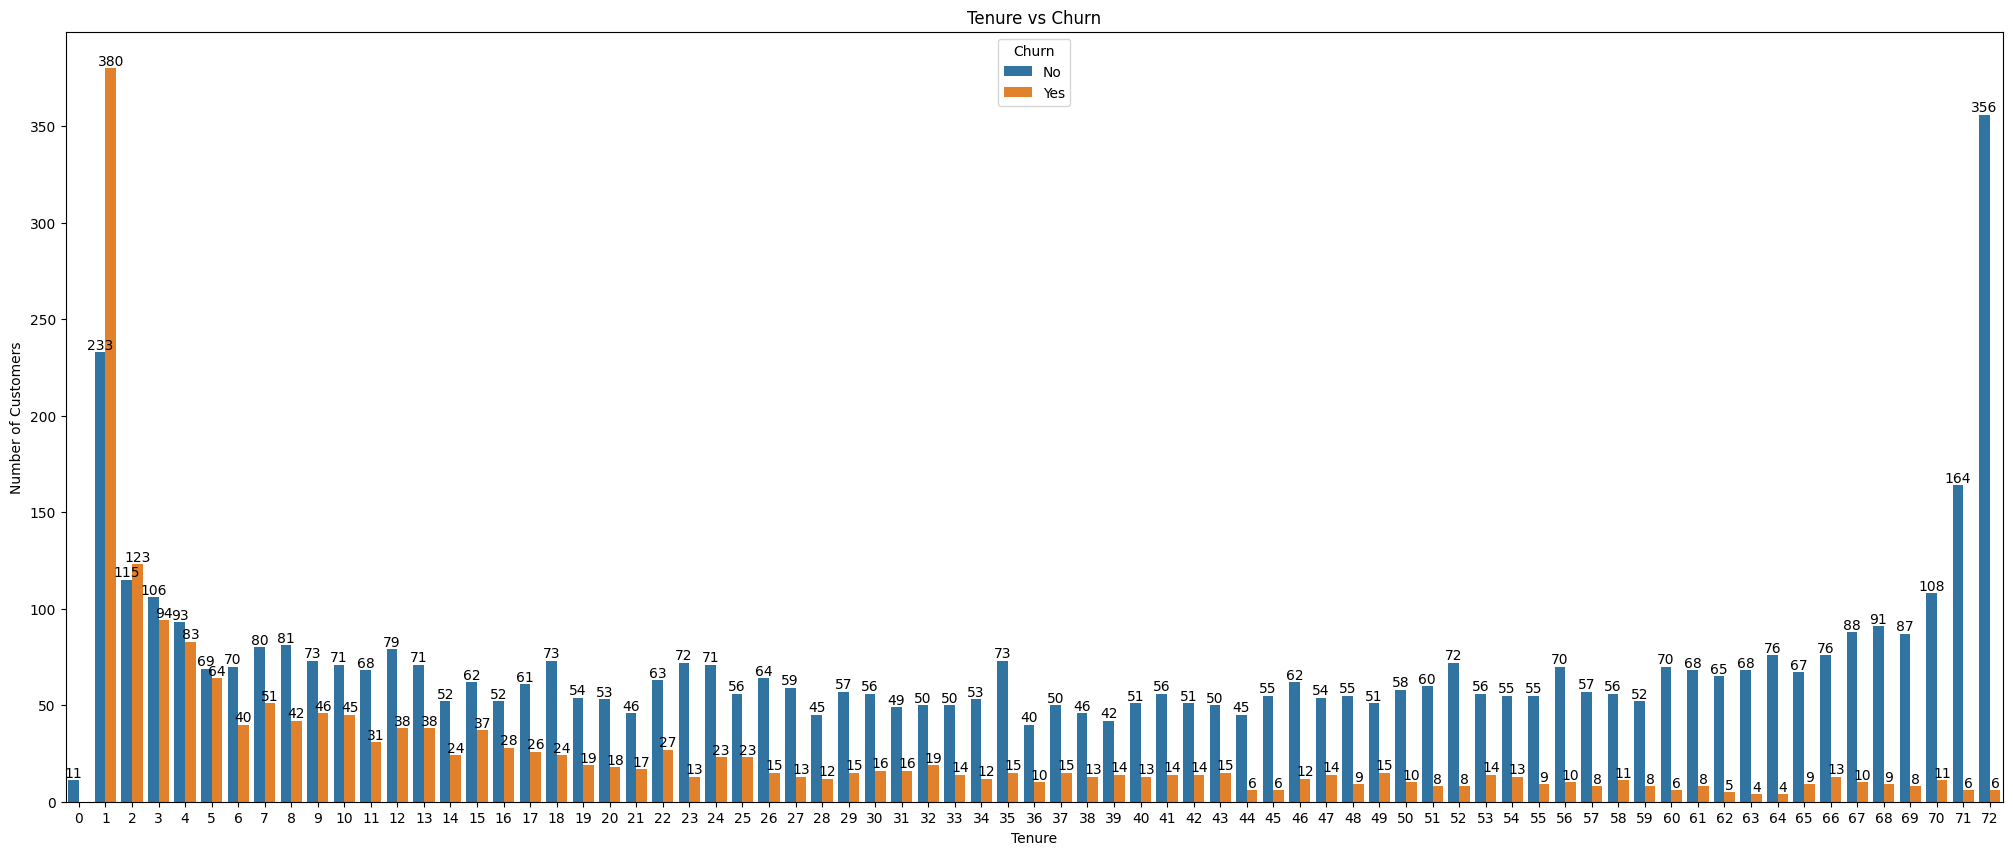

In [8]:
plt.figure(figsize=(25,10))

ax = sns.countplot(
    data=df,
    x="tenure",
    hue="Churn"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Tenure vs Churn")
plt.xlabel("Tenure")
plt.ylabel("Number of Customers")
plt.show()

**Customer churn by Tenure group**

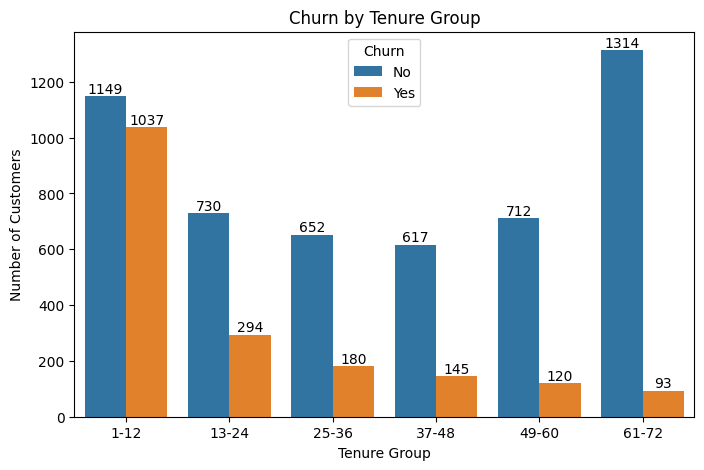

In [9]:
df["TenureGroup"] = pd.cut(df["tenure"],bins=[-1,12,24,36,48,60,72],labels=["1-12","13-24","25-36","37-48","49-60","61-72"])

plt.figure(figsize=(8,5))
ax = sns.countplot(data=df,x="TenureGroup",hue="Churn")

for container in ax.containers:
    ax.bar_label(container)

plt.title("Churn by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Number of Customers")
plt.show()



##1. Customers with **lower tenure churns more** (when tenure is less than 12)



# **Customer Churn By Services**

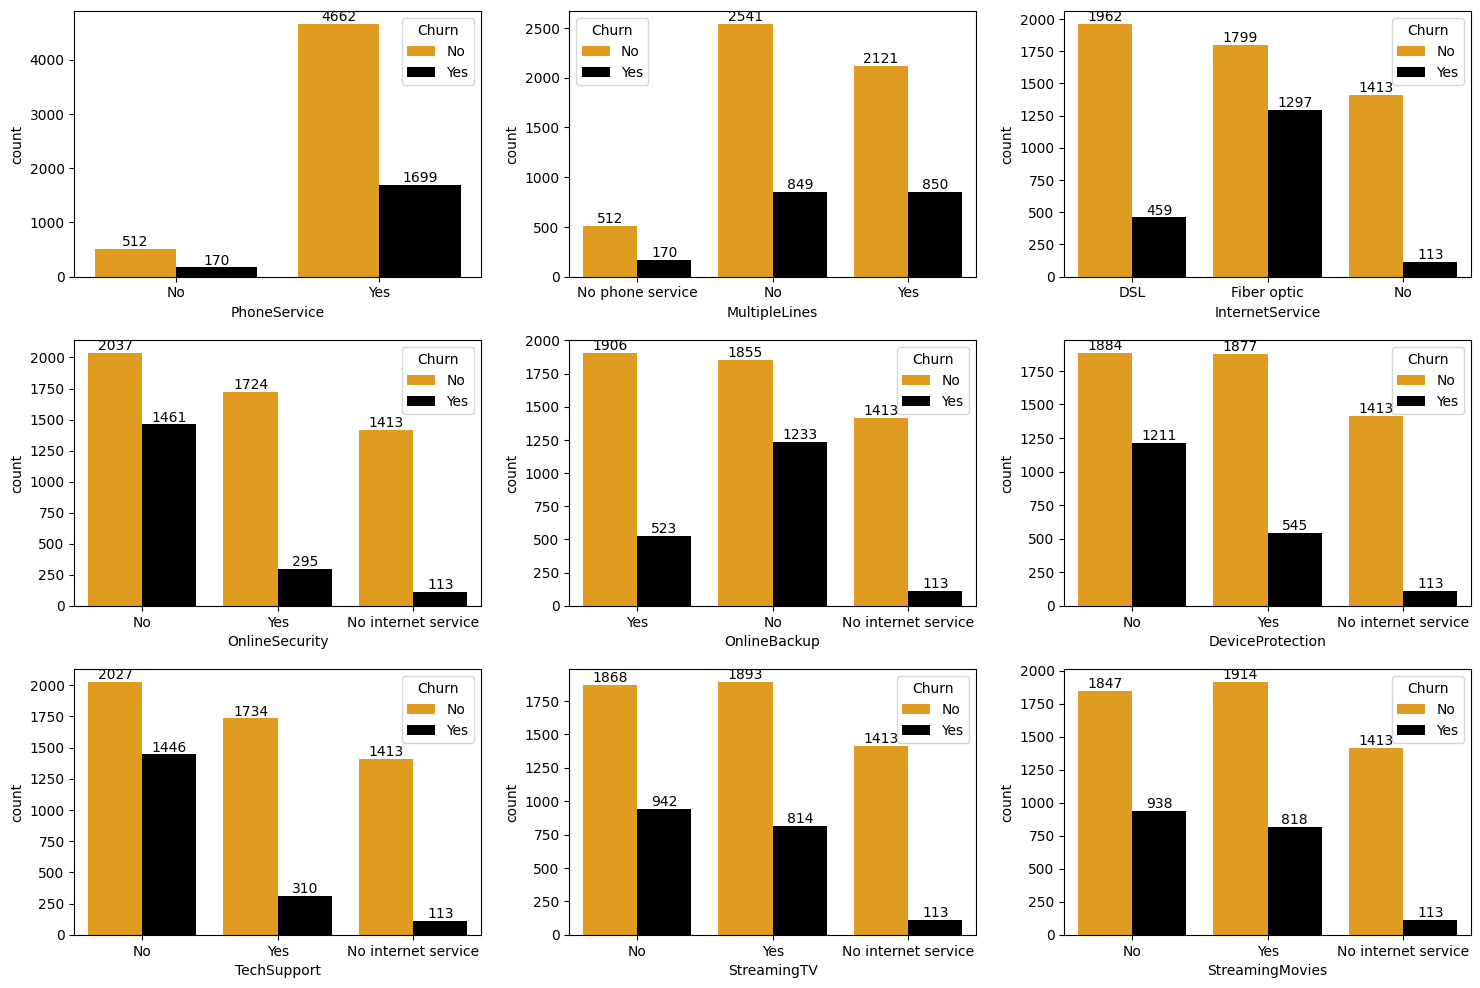

In [10]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))

palette = {
    "Yes": "black",
    "No": "orange"
}

sns.countplot(data=df, x="PhoneService", hue="Churn", palette=palette,ax=axes[0,0])
sns.countplot(data=df, x="MultipleLines", hue="Churn",  palette=palette,ax=axes[0,1])
sns.countplot(data=df, x="InternetService", hue="Churn",  palette=palette,ax=axes[0,2])
sns.countplot(data=df, x="OnlineSecurity", hue="Churn",  palette=palette,ax=axes[1,0])

sns.countplot(data=df, x="OnlineBackup", hue="Churn",  palette=palette,ax=axes[1,1])
sns.countplot(data=df, x="DeviceProtection", hue="Churn",  palette=palette,ax=axes[1,2])
sns.countplot(data=df, x="TechSupport", hue="Churn",  palette=palette,ax=axes[2,0])
sns.countplot(data=df, x="StreamingTV", hue="Churn",  palette=palette,ax=axes[2,1])
sns.countplot(data=df, x="StreamingMovies", hue="Churn", palette=palette, ax=axes[2,2])

for ax in axes.flat:
    for x in ax.containers:
        ax.bar_label(x, fmt='%d')

plt.tight_layout()
plt.show()



*   Customer with Internet Service of Fiber Optics Churns higher.
*   Customer with Internet Service along Online Security Churns higher.
*   Customer with Internet Service and no Online Backup Churns higher.
*   Customer with Internet Service and no Device Protection Churns more.
*   Customer with Internet Service and no Tech Support Churns higher.
*   Customer with Internet Service along Streaming TV as well as no Streaming TV service churns higher.
*   Customer with Internet Service along Streaming Movies as well as no Streaming TV service churns more.

# **Customer Churn By Contract & Paymnet**

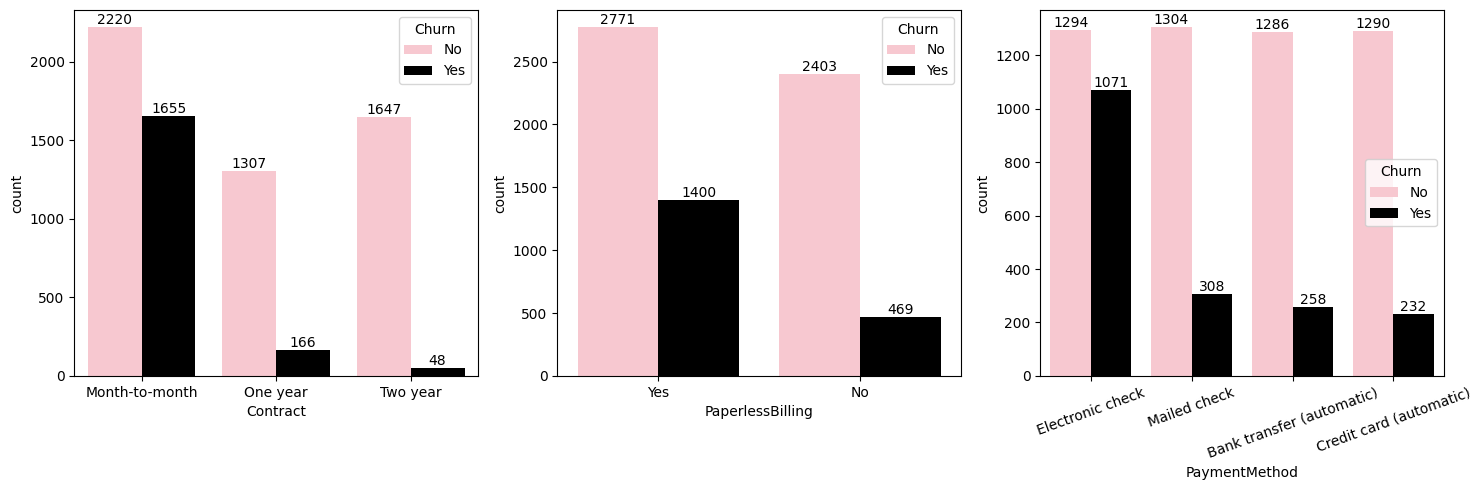

In [11]:
fig,axes=plt.subplots(1,3,figsize=(15,5))

palette={
    'Yes':'black',
    'No':'pink'
}

sns.countplot(data=df,x="Contract",hue="Churn", palette=palette,ax=axes[0])
sns.countplot(data=df,x="PaperlessBilling",hue="Churn", palette=palette,ax=axes[1])
sns.countplot(data=df,x="PaymentMethod",hue="Churn", palette=palette,ax=axes[2])
plt.xticks(rotation=20)

for ax in axes.flat:
  for container in ax.containers:
    ax.bar_label(container,fmt="%d")

plt.tight_layout()
plt.show()



## 1.Customers highly Churn more with Month-to-Month Compared to One year &   Two year contarct .
## 2.   Customer with paperless billing churns more.
## 3.   Customers highly churn more with Electronic Check Payment Method




# **Customer Churn By Billing**

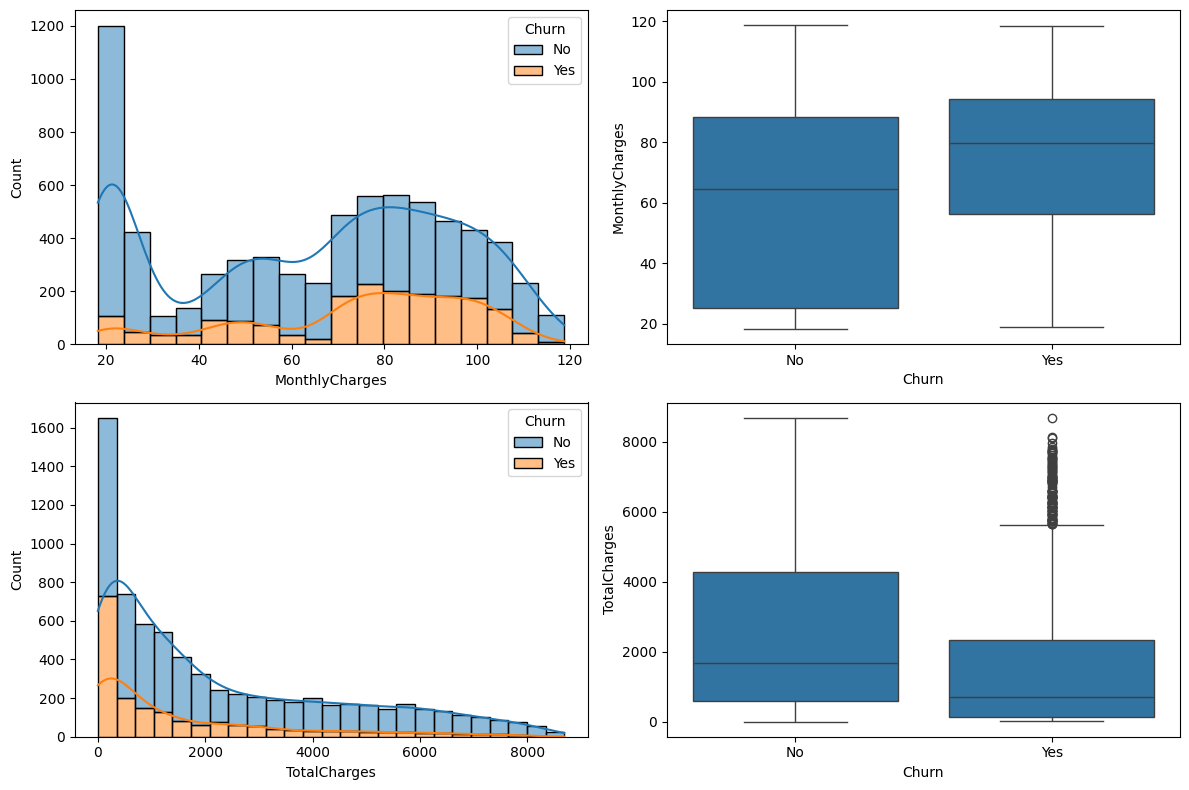

In [12]:
fig,axes=plt.subplots(2,2,figsize=(12,8))

# MONTHLY CHARGES
sns.histplot(data=df,x="MonthlyCharges",hue="Churn",kde=True,multiple="stack",ax=axes[0,0])
sns.boxplot(data=df,x="Churn",y="MonthlyCharges",ax=axes[0,1])

# TOTAL CHARGES
sns.histplot(data=df,x="TotalCharges",hue="Churn",kde=True,multiple="stack",ax=axes[1,0])
sns.boxplot(data=df,x="Churn",y="TotalCharges",ax=axes[1,1])

plt.tight_layout()
plt.show()


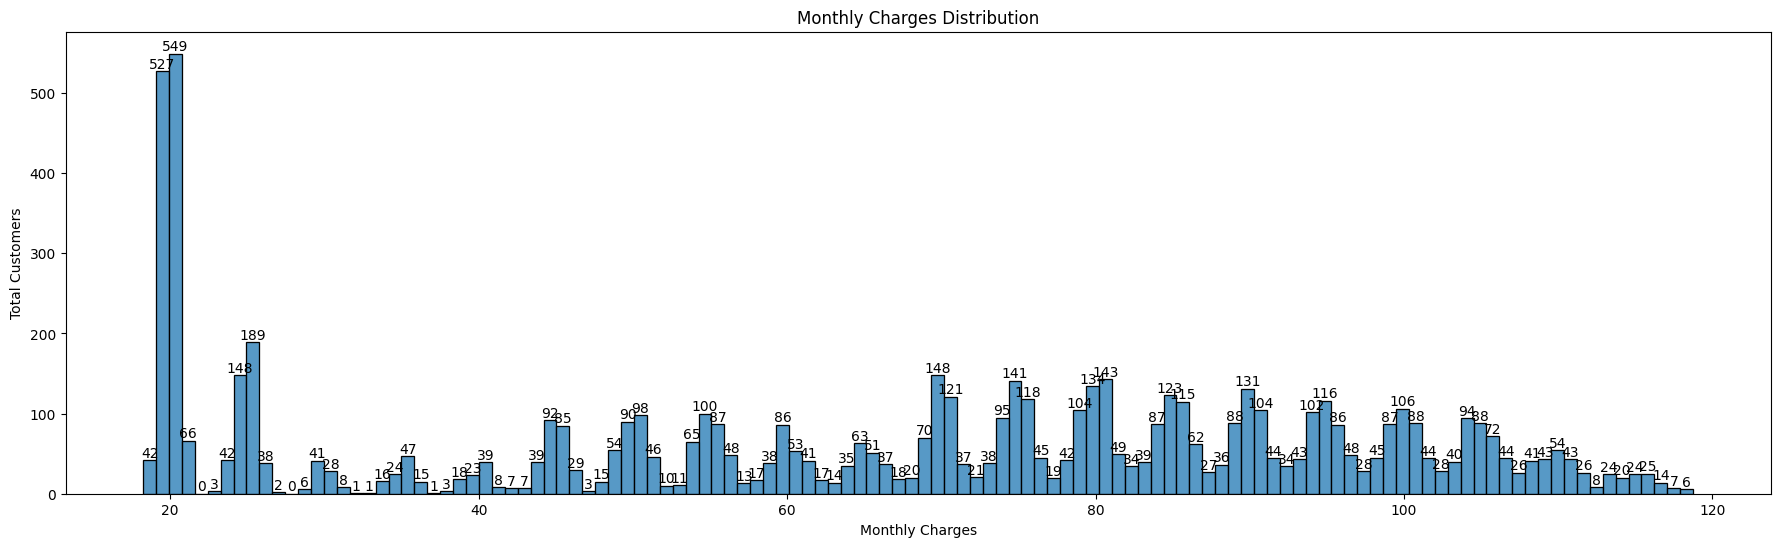

In [13]:
plt.figure(figsize=(22,6))
mon_chr=sns.histplot(df["MonthlyCharges"],bins=120)

for x in mon_chr.containers:
  mon_chr.bar_label(x)

plt.title("Monthly Charges Distribution")
plt.xlabel("Monthly Charges")
plt.ylabel("Total Customers")
plt.show()

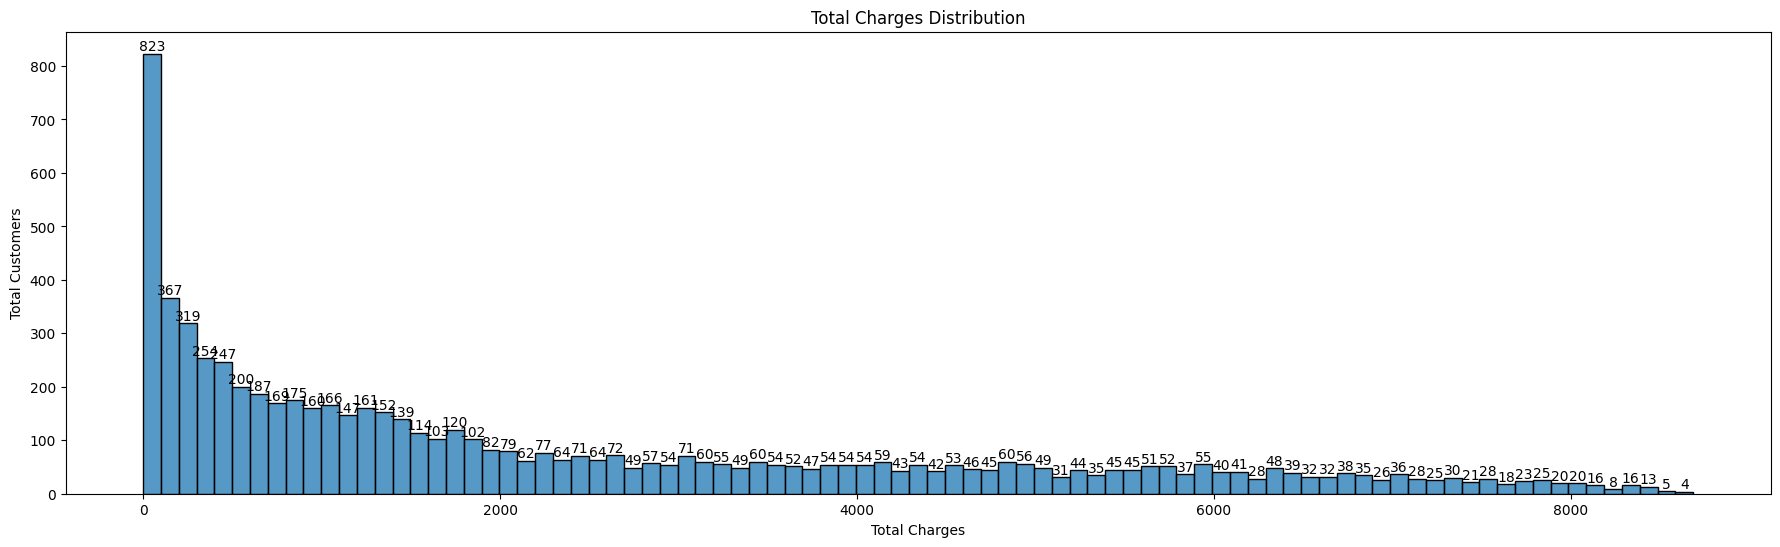

In [14]:
plt.figure(figsize=(22,6))
total_chr=sns.histplot(df["TotalCharges"],bins=87)

for x in total_chr.containers:
  total_chr.bar_label(x)

plt.title("Total Charges Distribution")
plt.xlabel("Total Charges")
plt.ylabel("Total Customers")
plt.show()



*   Customers with Monthly Charges between 50-90 Churns more.
*   Customers with Total Charges between 200-2200 Churns more.



# **Churn Customers**

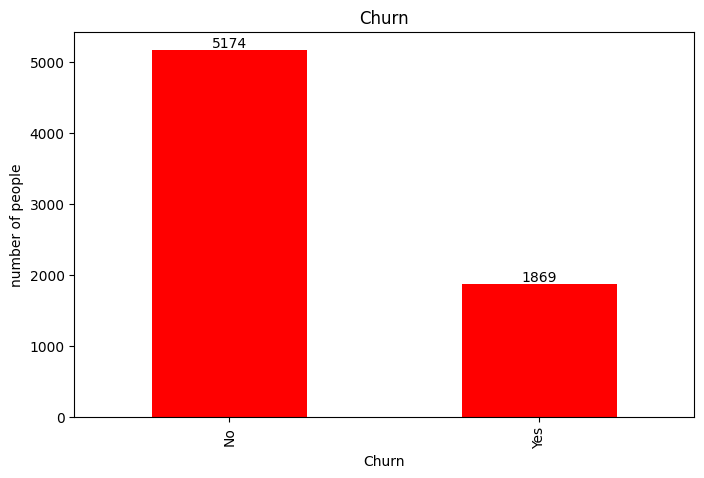

In [15]:
churn=df["Churn"].value_counts().plot(kind="bar",title="Churn",xlabel="Churn" ,ylabel="number of people",color="r",figsize=(8,5))
for x in churn.containers:
    churn.bar_label(x)

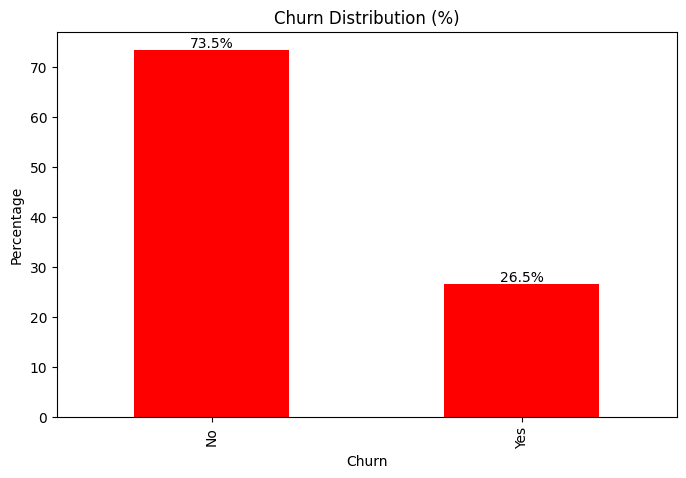

In [16]:
import matplotlib.pyplot as plt

churn_pct = df["Churn"].value_counts(normalize=True) * 100

ax = churn_pct.plot(
    kind="bar",
    title="Churn Distribution (%)",
    xlabel="Churn",
    ylabel="Percentage",
    color="r",
    figsize=(8,5)
)

for x in ax.containers:
    ax.bar_label(x, fmt="%.1f%%")

plt.show()



*   Customer churn rate is lower compared to customer stays.
*   Total customer stays 5174 and total customer churns 1869.



# Correlation

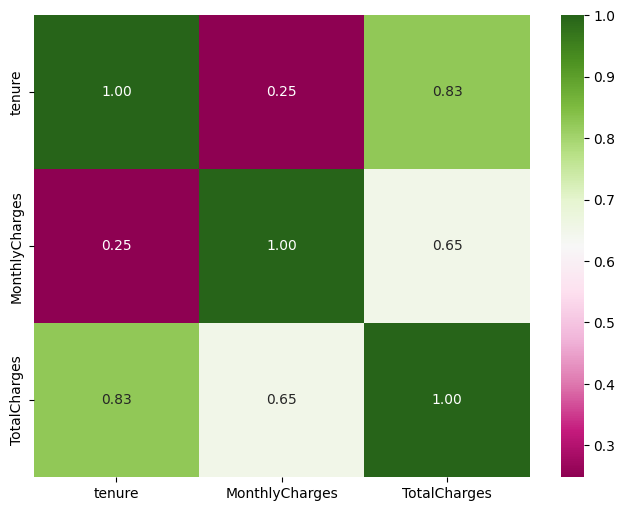

In [17]:
num_cols = ["tenure","MonthlyCharges","TotalCharges"]

plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols].corr(),annot=True,cmap="PiYG",fmt=".2f")
plt.show()

## Correlation Analysis

The heatmap illustrates the Pearson correlation coefficients among the numerical features: **tenure**, **MonthlyCharges**, and **TotalCharges**.

### Key Observations

#### 1. Tenure vs TotalCharges
- A strong positive correlation is observed between **tenure** and **TotalCharges**.
- This indicates that customers who remain with the company for a longer period tend to accumulate higher total charges.
- The relationship is expected because TotalCharges increases over time as customers continue using the service.

#### 2. MonthlyCharges vs TotalCharges
- A moderate to strong positive correlation exists between **MonthlyCharges** and **TotalCharges**.
- Customers with higher monthly bills generally contribute more revenue over their lifetime.
- However, the correlation is not perfect because TotalCharges is also influenced by customer tenure.

#### 3. Tenure vs MonthlyCharges
- A relatively weak correlation is observed between **tenure** and **MonthlyCharges**.
- This suggests that the amount a customer pays monthly is largely independent of how long they remain with the company.
- Both new and long-term customers can have either high or low monthly charges.

### Business Insights

- **TotalCharges** is strongly influenced by both customer tenure and monthly spending.
- Long-tenure customers generate higher lifetime revenue for the company.
- The strong relationship between **TotalCharges** and **tenure** should be considered during feature selection, as it may contribute to multicollinearity in certain machine learning models.

### Conclusion

The correlation analysis reveals that **TotalCharges** is closely related to both **tenure** and **MonthlyCharges**, which aligns with the business logic of the telecom industry. No unexpected relationships are observed among the numerical variables, indicating that the dataset is consistent and suitable for further exploratory data analysis and predictive modeling.

- **Tenure** and **TotalCharges** show a strong positive correlation (**r = 0.83**).
- **MonthlyCharges** and **TotalCharges** show a moderate positive correlation (**r = 0.65**).
- **Tenure** and **MonthlyCharges** show a weak positive correlation (**r = 0.25**).


**Recommendations**

* 1. Offer discounts for annual contracts.
* 2. Create retention campaigns for customers <12 months.
* 3. Encourage migration from Electronic Check.
* 4. Bundle Tech Support and Online Security services.
* 5. Target Fiber Optic customers with loyalty programs.



# 📊 Business Recommendations

## 1. Launch an Early-Life Retention Program

### Finding
Customers with **tenure below 12 months** have the highest churn risk.

### Recommendation
Create a **90-day and 180-day onboarding program** that includes:

- Welcome calls
- Service setup assistance
- Product usage tips and tutorials
- First-year loyalty rewards and incentives

### Business Impact
Reducing churn during the first year can significantly increase **Customer Lifetime Value (CLV)** and improve long-term customer retention.

---

## 2. Convert Month-to-Month Customers to Long-Term Contracts

### Finding
Customers on **Month-to-Month contracts** churn substantially more than customers on annual or multi-year contracts.

### Recommendation
Encourage contract upgrades by offering:

- 10–15% discounts on annual plans
- Free streaming or entertainment add-ons
- Loyalty points and retention rewards

### Business Impact
Long-term contracts improve customer retention, increase revenue stability, and enhance forecasting accuracy.

---

## 3. Improve Fiber Optic Customer Experience

### Finding
Customers using **Fiber Optic Internet Services** exhibit elevated churn rates.

### Recommendation
Conduct a root-cause analysis focusing on:

- Service quality issues
- Network outages and reliability
- Customer complaints and support tickets
- Pricing competitiveness

Additionally, prioritize retention campaigns for Fiber customers identified as high-risk by the churn prediction model.

### Business Impact
Protects a high-value customer segment and reduces revenue loss from premium service customers.

---

## 4. Promote Value-Added Services

### Finding
Customers without the following services churn more frequently:

- Online Security
- Tech Support
- Online Backup
- Device Protection

### Recommendation
Create bundled service packages such as:

**Internet + Online Security + Tech Support**

Offer free trial periods for:

- Online Security
- Tech Support
- Device Protection

### Business Impact
Increases customer engagement, service dependency, and overall retention.

---

## 5. Reduce Electronic Check Dependency

### Finding
Customers using **Electronic Check** as their payment method have higher churn rates.

### Recommendation
Encourage migration to automated payment methods:

- Auto-Pay
- Credit Card Auto Billing
- Bank Transfer Auto Billing

Provide incentives such as:

- Cashback rewards
- Monthly billing discounts
- Loyalty bonuses

### Business Impact
Improves payment reliability while reducing customer churn.

---

## 6. Deploy Predictive Churn Monitoring

### Finding
The machine learning churn prediction model can identify customers at high risk of leaving before churn occurs.

### Recommendation
Develop a weekly churn monitoring dashboard that tracks:

- High-risk customers
- Churn probability scores
- Key churn drivers
- Customer segments at risk

Automate retention actions for customers exceeding a predefined risk threshold.

### Business Impact
Transforms retention strategy from **reactive** to **proactive**, reducing customer loss and maximizing retention efforts.

---

# 🎯 Strategic Priority Ranking

| Priority | Initiative | Expected Impact |
|----------|------------|----------------|
| 1 | Early-Life Retention Program | Very High |
| 2 | Month-to-Month Contract Conversion | Very High |
| 3 | Predictive Churn Monitoring | High |
| 4 | Fiber Optic Experience Improvement | High |
| 5 | Value-Added Service Bundling | Medium-High |
| 6 | Electronic Check Migration Campaign | Medium |

---

## Executive Summary

Analysis of customer churn patterns reveals that churn is primarily driven by:

- Short customer tenure
- Month-to-Month contracts
- Fiber Optic service customers
- Lack of value-added services
- Electronic Check payment usage

By implementing targeted retention initiatives, contract conversion programs, service bundling strategies, and predictive churn monitoring, the company can significantly reduce churn, improve customer lifetime value, and create more predictable recurring revenue streams.